# PA1 — Task 2 v2: Unsupervised Domain Adaptation on PACS

**The experiment in one line.** Train a ResNet-18 on Photo + Art Painting + Cartoon (labelled) and see
whether using unlabelled Sketch images during training makes it better on Sketch.

**The four methods**, all sharing one training loop so the only difference is the loss:

| Run | What it adds to plain supervised training |
|---|---|
| `source_only` | nothing (the baseline; also Task 3's ERM baseline) |
| `dan` | a penalty (MMD) that pulls source and target feature clouds together |
| `dann` | a discriminator that guesses the domain, which the backbone is trained to fool |
| `cdan` | the same, but the discriminator also sees the predicted class |

Plus two extra runs for the controlled study (λ_MMD = 0.1 and 10).

**What changed in v2.** Gradient clipping (global norm 1.0) now applies to every method. Without it,
DANN and CDAN diverged in the first epoch: the gradient-reversal layer maximises a domain loss with no
upper limit, so features and discriminator weights grew without bound. Clipping bounds the step size
without changing any objective or the handout's optimiser settings.

**Before you start**
1. Upload `pa1-task2-v2.zip` to the top level of **My Drive**.
2. Your repository is at **My Drive/PA1** (change `REPO` in A3 if not).
3. **Runtime → Change runtime type → T4 GPU → Save**.

**Rules this notebook enforces.** Sketch labels are used only in Part C, after every checkpoint is
frozen. Checkpoints are chosen on source-validation macro-F1 alone. Every cell prints what it did and
what the numbers mean, so you can read the notebook top to bottom as a record of the experiment.

## Part A — setup

Re-run this whole part whenever Colab gives you a fresh machine (after a disconnect, or the next day).
It mounts Drive, installs the Task 2 code, fetches PACS onto local disk and loads the fixed splits.
Nothing here trains anything.

In [1]:
# A1. Check that a GPU is attached. Training on CPU would take many hours.
import subprocess
out = subprocess.run('nvidia-smi --query-gpu=name,memory.total --format=csv,noheader',
                     shell=True, capture_output=True, text=True).stdout.strip()
print(f'GPU: {out}' if out else 'NO GPU -- go to Runtime > Change runtime type > T4 GPU, then re-run this cell.')

GPU: Tesla T4, 15360 MiB


In [2]:
# A2. Mount Google Drive so the notebook can read the repository and write results that survive a disconnect.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# A3. Install the Task 2 v2 code into your repository.
# `-o` overwrites code and configs deliberately. Results, splits and Task 1 files are untouched:
# the zip contains no results and no shared/splits. Your own task2/README.md is backed up first.
import os, shutil
DRIVE = '/content/drive/MyDrive'
REPO = f'{DRIVE}/PA1'                       # <- change if your repo folder has another name
ZIP = f'{DRIVE}/pa1-task2-v2.zip'
assert os.path.isdir(REPO), f'Repository not found at {REPO}'
assert os.path.exists(ZIP), f'Upload pa1-task2-v2.zip to My Drive first (expected {ZIP})'
if os.path.exists(f'{REPO}/task2/README.md') and not os.path.exists(f'{REPO}/task2/README_yours.md'):
    shutil.copy(f'{REPO}/task2/README.md', f'{REPO}/task2/README_yours.md')
    print('Your task2/README.md was copied to task2/README_yours.md before being replaced.')
!unzip -q -o "{ZIP}" -d "{REPO}"
%cd {REPO}
print('\nRepository contents:')
!ls
print('\nClipping setting now in force (this is the v2 change):')
!grep -A2 "grad_clip" task2/configs/base.yaml

/content/drive/MyDrive/PA1

Repository contents:
common	   README.md  requirements.txt	task1  third_party
notebooks  report     shared		task2

Clipping setting now in force (this is the v2 change):
grad_clip: 1.0          # max global gradient norm, applied identically to every method.
                        # Without it the adversarial methods (DANN/CDAN) diverge: the reversed
                        # gradient maximises an unbounded domain loss. Report this choice.


In [4]:
# A3b. Move the old pre-clipping runs aside, so Part B starts from scratch while the evidence is kept
# (they are worth one paragraph in the report as an instability finding).
if os.path.isdir('task2/results/runs') and not os.path.isdir('task2/results/runs_noclip'):
    shutil.move('task2/results/runs', 'task2/results/runs_noclip')
    print('Old runs archived -> task2/results/runs_noclip')
elif os.path.isdir('task2/results/runs_noclip'):
    print('Old runs were already archived in task2/results/runs_noclip -- nothing to do.')
else:
    print('No previous runs found -- nothing to archive.')

No previous runs found -- nothing to archive.


In [5]:
# A4. Helpers used by the rest of the notebook. Run this every session.
#   run(cmd)          -> runs a shell command, streams its output live, stops the notebook on failure
#   report(run_name)  -> prints a health summary of one finished training run and plots its curves
import subprocess, json, math
import pandas as pd
import matplotlib.pyplot as plt

CHANCE_LOSS = math.log(7)          # 1.946 -- cross-entropy of a model that guesses uniformly over 7 classes
CLIP = 1.0                         # the gradient-clipping threshold set in task2/configs/base.yaml

def run(cmd):
    print('$', cmd, flush=True)
    p = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
    if p.wait() != 0:
        raise RuntimeError(f'Command failed (exit code {p.returncode}): {cmd}')

def report(run_name):
    """Print what happened in one run, then plot its curves.

    The four things worth checking, in order:
      1. classification loss    -- must end far below 1.95; stuck at ~1.95 means the classifier collapsed
      2. alignment/domain loss  -- MMD should fall; the DANN/CDAN domain loss should settle near 0.69 (= ln 2,
                                   i.e. the discriminator is guessing)
      3. discriminator accuracy -- should drift from ~1.0 down toward 0.5 as alpha grows (DANN/CDAN only)
      4. gradient norm          -- pre-clipping; values above 1.0 mean clipping was active
    """
    d = f'task2/results/runs/{run_name}'
    s, hist = json.load(open(f'{d}/summary.json')), json.load(open(f'{d}/history.json'))
    ep = [h['epoch'] for h in hist]
    f1 = [h['val_mean_macro_f1'] for h in hist]
    cls = [h['loss_cls'] for h in hist]
    gn = [h.get('grad_norm', float('nan')) for h in hist]
    best_ep = ep[int(pd.Series(f1).idxmax())]

    print(f'\n=== {run_name} ===')
    print(f'  epochs run              : {s["epochs_run"]} of {s["config"]["max_epochs"]} '
          f'({"early stop" if s["epochs_run"] < s["config"]["max_epochs"] else "full budget"})')
    print(f'  best source-val macro-F1: {s["best_mean_macro_f1"]:.2f}  (epoch {best_ep} -- this checkpoint is the one saved)')
    print(f'  classification loss     : {cls[0]:.3f} -> {cls[-1]:.3f}   (1.95 = chance for 7 classes)')
    for k, label in [('loss_mmd', 'MMD alignment loss     '), ('loss_dom', 'domain loss            ')]:
        if k in hist[0]:
            print(f'  {label} : {hist[0][k]:.3f} -> {hist[-1][k]:.3f}' + ('   (0.69 = discriminator guessing)' if k == 'loss_dom' else ''))
    if 'disc_acc' in hist[0]:
        print(f'  discriminator accuracy  : {100*hist[0]["disc_acc"]:.1f}% -> {100*hist[-1]["disc_acc"]:.1f}%   (50% = fully confused)')
    clipped = sum(g > CLIP for g in gn if g == g)
    print(f'  gradient norm           : max {max(gn):.2f}, clipping active on {clipped}/{len(gn)} epochs')

    if min(cls) > 1.6 or s['best_mean_macro_f1'] < 50:
        print('  VERDICT: COLLAPSED -- this run never learned the classes. Do not use it; send it to Claude.')
    elif cls[-1] > 1.6 or s['best_mean_macro_f1'] < 80:
        print('  VERDICT: unstable -- it learned something but degraded. Worth a closer look before Part C.')
    else:
        print('  VERDICT: looks healthy.')

    panels = [('loss_cls', 'classification loss', CHANCE_LOSS, 'chance (ln 7)')]
    if 'loss_mmd' in hist[0]: panels.append(('loss_mmd', 'MMD alignment loss', None, None))
    if 'loss_dom' in hist[0]: panels.append(('loss_dom', 'domain loss', math.log(2), 'ln 2'))
    if 'disc_acc' in hist[0]: panels.append(('disc_acc', 'discriminator accuracy', 0.5, 'chance'))
    panels += [('val_mean_macro_f1', 'mean source-val macro-F1', None, None), ('grad_norm', 'gradient norm (pre-clip)', CLIP, 'clip threshold')]
    fig, axes = plt.subplots(1, len(panels), figsize=(3.1 * len(panels), 2.6))
    for ax, (key, title, line, lbl) in zip(axes, panels):
        ax.plot(ep, [h.get(key, float('nan')) for h in hist], marker='.')
        if line is not None:
            ax.axhline(line, color='r', ls=':', lw=1, label=lbl); ax.legend(fontsize=7)
        ax.set_title(f'{run_name}: {title}', fontsize=8); ax.set_xlabel('epoch'); ax.grid(alpha=.3)
    fig.tight_layout(); plt.show()

print('Helpers ready: run(cmd), report(run_name)')

Helpers ready: run(cmd), report(run_name)


In [6]:
# A5. Get PACS onto Colab's local disk. Reading ~10,000 small files from Drive during training
# would be far slower than the GPU. The first session downloads it and saves a zip backup to Drive;
# later sessions just restore that backup (about a minute).
import glob
PACS = '/content/data/PACS'
DRIVE_ZIP = f'{DRIVE}/datasets/PACS.zip'
EXPECTED = {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929}   # published PACS sizes

if not os.path.isdir(f'{PACS}/sketch'):
    os.makedirs('/content/data', exist_ok=True)
    if os.path.exists(DRIVE_ZIP):
        print('Restoring PACS from your Drive backup ...')
        run(f'unzip -q "{DRIVE_ZIP}" -d /content/data')
    else:
        try:
            run('python -m shared.download_pacs --root /content/data')      # DomainBed's Google Drive link
        except RuntimeError:
            print('Google Drive rate-limited the file -- falling back to a GitHub mirror ...')
            run('git clone -q --depth 1 https://github.com/MachineLearning2020/Homework3-PACS /content/pacs_mirror')
            hits = [os.path.dirname(p) for p in glob.glob('/content/pacs_mirror/**/sketch', recursive=True)
                    if all(os.path.isdir(os.path.join(os.path.dirname(p), d)) for d in EXPECTED)]
            assert hits, 'Could not find the four PACS domain folders in the mirror'
            shutil.move(hits[0], PACS)
        os.makedirs(f'{DRIVE}/datasets', exist_ok=True)
        print('Backing up PACS to Drive so future sessions skip the download ...')
        run(f'cd /content/data && zip -qr "{DRIVE_ZIP}" PACS')

print('\nImage counts (these must match the published dataset, or the copy is incomplete):')
ok = True
for d, n in EXPECTED.items():
    got = len([p for p in glob.glob(f'{PACS}/{d}/*/*') if p.lower().endswith(('.jpg', '.jpeg', '.png'))])
    ok &= got == n
    print(f'  {d:13s} {got:5d}  (expected {n})' + ('' if got == n else '   <-- MISMATCH'))
print('\nPACS looks complete.' if ok else '\nSomething is missing -- send this output to Claude before training.')

Restoring PACS from your Drive backup ...
$ unzip -q "/content/drive/MyDrive/datasets/PACS.zip" -d /content/data

Image counts (these must match the published dataset, or the copy is incomplete):
  photo          1670  (expected 1670)
  art_painting   2048  (expected 2048)
  cartoon        2344  (expected 2344)
  sketch         3929  (expected 3929)

PACS looks complete.


In [7]:
# A6. Load the shared PACS split (seed 6304), creating it if this is the first session.
# Two separate files on purpose:
#   pacs_sources_seed6304.json  - the 80/20 train/val split of each SOURCE domain (the only file Task 3 may read)
#   pacs_sketch_target.json     - every Sketch image; used unlabelled in training, labelled only in Part C
if not os.path.exists('shared/splits/pacs_sources_seed6304.json'):
    run(f'python -m shared.pacs_protocol --root {PACS}')
else:
    print('Splits already exist -- reusing them, so these runs see exactly the same images as before.\n')
src = json.load(open('shared/splits/pacs_sources_seed6304.json'))['domains']
tr = sum(len(s['train']) for s in src.values())
for d, s in src.items():
    print(f'  {d:13s} train={len(s["train"]):5d}  val={len(s["val"]):4d}')
n_sketch = len(json.load(open('shared/splits/pacs_sketch_target.json'))['items'])
print(f'  {"sketch":13s} all={n_sketch} (no labels during training)')
print(f'\nSource training images: {tr}. With 24 source images per update, one epoch = {tr // 24} updates,')
print(f'so the 30-epoch budget is {30 * (tr // 24)} updates. The alpha schedule in DANN/CDAN is measured against that.')

Splits already exist -- reusing them, so these runs see exactly the same images as before.

  photo         train= 1336  val= 334
  art_painting  train= 1638  val= 410
  cartoon       train= 1875  val= 469
  sketch        all=3929 (no labels during training)

Source training images: 4849. With 24 source images per update, one epoch = 202 updates,
so the 30-epoch budget is 6060 updates. The alpha schedule in DANN/CDAN is measured against that.


## Part B — training

**What one update looks like.** 8 photo + 8 art + 8 cartoon images (domain-balanced on purpose, since
cartoon has 40% more images than photo), plus 24 unlabelled sketches for the adaptation methods. Forward,
compute the method's loss, backward, clip the gradient to norm 1.0, one AdamW step (lr 1e-4, weight decay 1e-4).

**What is identical across all six runs:** initialisation, source batches and their augmentation (each
loader has its own seed), the optimiser, the 30-epoch budget, early stopping after 5 epochs without
improvement, frozen BatchNorm statistics, and the checkpoint rule (best mean macro-F1 over the three
source validation splits). Only the loss differs.

**What you see during a run.** One line per epoch, then a health summary and curves printed by `report()`.
No target labels are involved, so everything printed here is safe to look at.

**Before the first run:** write your hypotheses down, including what you expect increasing alignment
pressure to do to source performance, domain separability and Sketch accuracy. The handout requires that
they are stated before you interpret results.

In [8]:
# B0. The run list, and the helper that trains one configuration.
# Finished runs are skipped, so you can close Colab and continue later.
STUDY = 'dan'     # 'dan'  -> lambda_MMD in {0.1, 1, 10}   (recommended: it mirrors Task 3's lambda study)
                  # 'dann' -> maximum gradient-reversal strength in {0.25, 0.5, 1}
COMMON = f'--set data_root={PACS}'
RUNS = [('source_only', 'source_only'), ('dan', 'dan'), ('dann', 'dann'), ('cdan', 'cdan')]
RUNS += ([('study_dan_lambda0.1', 'dan_lambda0.1'), ('study_dan_lambda10', 'dan_lambda10')] if STUDY == 'dan' else
         [('study_dann_alpha0.25', 'dann_alpha0.25'), ('study_dann_alpha0.5', 'dann_alpha0.5')])

def train(config, run_name):
    if os.path.exists(f'task2/results/runs/{run_name}/summary.json'):
        print(f'{run_name}: already finished -- skipping (delete task2/results/runs/{run_name} to redo it)')
    else:
        run(f'python -m task2.train --config task2/configs/{config}.yaml {COMMON}')
    report(run_name)

print(f'Controlled study: {STUDY}. Six runs in total:\n')
for c, r in RUNS:
    state = 'done   ' if os.path.exists(f'task2/results/runs/{r}/summary.json') else 'pending'
    print(f'  {state}  {r:15s} (config: task2/configs/{c}.yaml)')

Controlled study: dan. Six runs in total:

  pending  source_only     (config: task2/configs/source_only.yaml)
  pending  dan             (config: task2/configs/dan.yaml)
  pending  dann            (config: task2/configs/dann.yaml)
  pending  cdan            (config: task2/configs/cdan.yaml)
  pending  dan_lambda0.1   (config: task2/configs/study_dan_lambda0.1.yaml)
  pending  dan_lambda10    (config: task2/configs/study_dan_lambda10.yaml)


$ python -m task2.train --config task2/configs/source_only.yaml --set data_root=/content/data/PACS
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth

  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 31%|███▏      | 14.0M/44.7M [00:00<00:00, 147MB/s]
 75%|███████▍  | 33.4M/44.7M [00:00<00:00, 180MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]
[source_only] ep01 loss_cls=0.5516 loss_total=0.5516 | val mean F1=88.61
[source_only] ep02 loss_cls=0.2657 loss_total=0.2657 | val mean F1=90.72
[source_only] ep03 loss_cls=0.1932 loss_total=0.1932 | val mean F1=88.78
[source_only] ep04 loss_cls=0.1737 loss_total=0.1737 | val mean F1=89.68
[source_only] ep05 loss_cls=0.1421 loss_total=0.1421 | val mean F1=91.98
[source_only] ep06 loss_cls=0.1179 loss_total=0.1179 | val mean F1=93.20
[source_only] ep07 loss_cls=0.1107 loss_total=0.1107 | val mean F1=91.55
[source_only] ep08 loss_cls=0.0999 loss_total=0.0999 | v

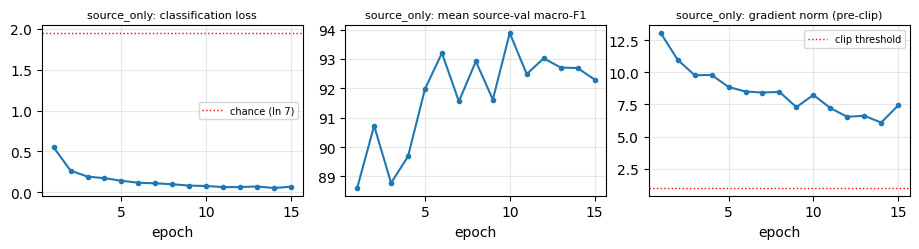

In [9]:
# B1. SOURCE-ONLY ERM -- plain supervised training on the three source domains; the target is never seen.
# Loss = cross-entropy on 24 source images. This checkpoint is also Task 3's ERM baseline.
# Expect: loss_cls falling from ~1.9 toward <0.1, source-val macro-F1 in the low 90s.
train('source_only', 'source_only')

$ python -m task2.train --config task2/configs/dan.yaml --set data_root=/content/data/PACS
[dan] ep01 loss_cls=0.5312 loss_mmd=0.2317 loss_total=0.7629 | val mean F1=91.81
[dan] ep02 loss_cls=0.2398 loss_mmd=0.1956 loss_total=0.4354 | val mean F1=91.72
[dan] ep03 loss_cls=0.1824 loss_mmd=0.1868 loss_total=0.3692 | val mean F1=91.71
[dan] ep04 loss_cls=0.1401 loss_mmd=0.1760 loss_total=0.3161 | val mean F1=92.92
[dan] ep05 loss_cls=0.1108 loss_mmd=0.1718 loss_total=0.2826 | val mean F1=93.14
[dan] ep06 loss_cls=0.1032 loss_mmd=0.1684 loss_total=0.2716 | val mean F1=91.58
[dan] ep07 loss_cls=0.0884 loss_mmd=0.1693 loss_total=0.2578 | val mean F1=93.29
[dan] ep08 loss_cls=0.0802 loss_mmd=0.1601 loss_total=0.2403 | val mean F1=92.99
[dan] ep09 loss_cls=0.0734 loss_mmd=0.1626 loss_total=0.2359 | val mean F1=91.72
[dan] ep10 loss_cls=0.0621 loss_mmd=0.1644 loss_total=0.2266 | val mean F1=93.19
[dan] ep11 loss_cls=0.0657 loss_mmd=0.1690 loss_total=0.2347 | val mean F1=92.82
[dan] ep12 loss_cl

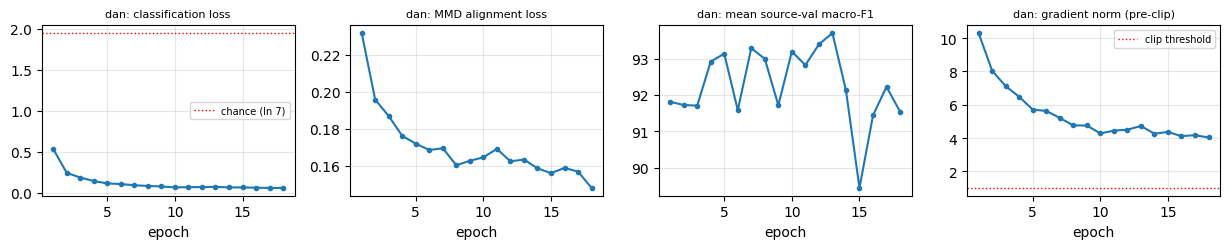

In [10]:
# B2. DAN -- adds lambda * MMD^2 between the 24 source and 24 target features (512-d, pre-head).
# MMD compares the two feature clouds through three RBF kernels whose width is set from the median
# pairwise distance in the current batch. It knows nothing about classes: marginal alignment.
# Expect: loss_mmd drifting down; loss_cls similar to Source-only.
train('dan', 'dan')

$ python -m task2.train --config task2/configs/dann.yaml --set data_root=/content/data/PACS
[dann] ep01 loss_cls=0.6377 loss_dom=2.5121 disc_acc=0.5391 alpha=0.0825 loss_total=3.1498 | val mean F1=68.69
[dann] ep02 loss_cls=94.1030 loss_dom=366.2378 disc_acc=0.4000 alpha=0.2440 loss_total=460.3408 | val mean F1=37.86
[dann] ep03 loss_cls=38.5207 loss_dom=169.5639 disc_acc=0.4664 alpha=0.3930 loss_total=208.0846 | val mean F1=16.76
[dann] ep04 loss_cls=237.0204 loss_dom=515.6297 disc_acc=0.5005 alpha=0.5239 loss_total=752.6500 | val mean F1=77.51
[dann] ep05 loss_cls=45.2548 loss_dom=77.1219 disc_acc=0.4833 alpha=0.6340 loss_total=122.3767 | val mean F1=46.17
[dann] ep06 loss_cls=109.2402 loss_dom=213.0450 disc_acc=0.4609 alpha=0.7233 loss_total=322.2852 | val mean F1=11.74
[dann] ep07 loss_cls=8198.5225 loss_dom=9744.9270 disc_acc=0.5598 alpha=0.7936 loss_total=17943.4495 | val mean F1=5.07
[dann] ep08 loss_cls=10819.2874 loss_dom=7711.6704 disc_acc=0.5039 alpha=0.8476 loss_total=18530

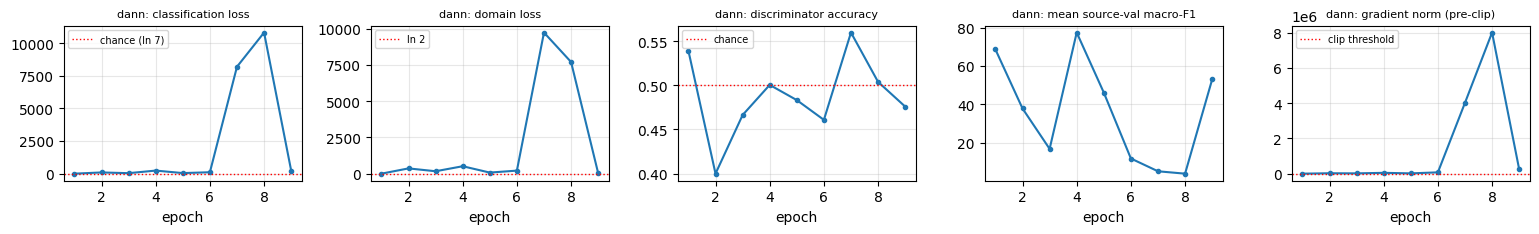

In [11]:
# B3. DANN -- replaces the statistic with an opponent: a 512->256->2 discriminator guesses the domain,
# and a gradient-reversal layer flips the sign of its gradient on the way back into the backbone, so the
# backbone learns to fool it. Strength alpha(p) ramps 0 -> 1 over the full 30-epoch budget.
# Expect: disc_acc drifting toward 50%, loss_dom toward 0.69, loss_cls staying LOW.
# If loss_cls parks near 1.95, the run has collapsed -- stop and send it to Claude.
train('dann', 'dann')

$ python -m task2.train --config task2/configs/cdan.yaml --set data_root=/content/data/PACS
[cdan] ep01 loss_cls=0.5468 loss_dom=0.5147 disc_acc=0.7699 alpha=0.0825 loss_total=1.0614 | val mean F1=87.17
[cdan] ep02 loss_cls=0.2923 loss_dom=0.6386 disc_acc=0.6603 alpha=0.2440 loss_total=0.9309 | val mean F1=87.97
[cdan] ep03 loss_cls=0.2887 loss_dom=0.7594 disc_acc=0.6184 alpha=0.3930 loss_total=1.0481 | val mean F1=88.22
[cdan] ep04 loss_cls=0.4196 loss_dom=0.9835 disc_acc=0.5650 alpha=0.5239 loss_total=1.4031 | val mean F1=88.74
[cdan] ep05 loss_cls=0.3295 loss_dom=0.7775 disc_acc=0.5650 alpha=0.6340 loss_total=1.1070 | val mean F1=90.30
[cdan] ep06 loss_cls=0.1616 loss_dom=0.7063 disc_acc=0.5944 alpha=0.7233 loss_total=0.8679 | val mean F1=91.49
[cdan] ep07 loss_cls=0.1605 loss_dom=0.7123 disc_acc=0.5346 alpha=0.7936 loss_total=0.8728 | val mean F1=87.61
[cdan] ep08 loss_cls=0.1808 loss_dom=0.7055 disc_acc=0.5375 alpha=0.8476 loss_total=0.8863 | val mean F1=93.39
[cdan] ep09 loss_cls

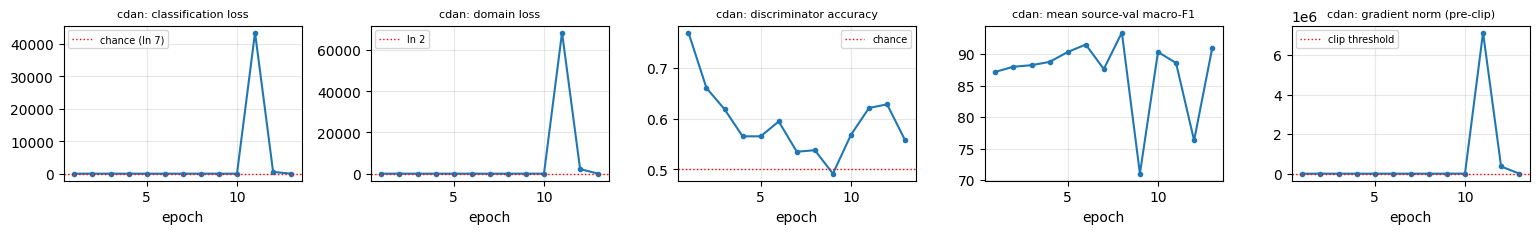

In [12]:
# B4. CDAN -- same game, but the discriminator sees the outer product of the 512 features and the 7 class
# probabilities (3,584 numbers), so alignment can respect class structure. As the handout requires: no
# entropy conditioning, and nothing detached, which means the reversed gradient also reaches the classifier
# head. That makes CDAN the most fragile method here.
train('cdan', 'cdan')

$ python -m task2.train --config task2/configs/study_dan_lambda0.1.yaml --set data_root=/content/data/PACS
[dan_lambda0.1] ep01 loss_cls=0.5316 loss_mmd=0.3599 loss_total=0.5676 | val mean F1=88.44
[dan_lambda0.1] ep02 loss_cls=0.2569 loss_mmd=0.2484 loss_total=0.2817 | val mean F1=90.10
[dan_lambda0.1] ep03 loss_cls=0.1789 loss_mmd=0.2326 loss_total=0.2021 | val mean F1=91.29
[dan_lambda0.1] ep04 loss_cls=0.1337 loss_mmd=0.2143 loss_total=0.1552 | val mean F1=89.41
[dan_lambda0.1] ep05 loss_cls=0.1037 loss_mmd=0.2084 loss_total=0.1246 | val mean F1=92.61
[dan_lambda0.1] ep06 loss_cls=0.0807 loss_mmd=0.2044 loss_total=0.1011 | val mean F1=93.57
[dan_lambda0.1] ep07 loss_cls=0.0669 loss_mmd=0.1884 loss_total=0.0857 | val mean F1=92.51
[dan_lambda0.1] ep08 loss_cls=0.0479 loss_mmd=0.1890 loss_total=0.0668 | val mean F1=92.95
[dan_lambda0.1] ep09 loss_cls=0.0541 loss_mmd=0.1793 loss_total=0.0721 | val mean F1=93.60
[dan_lambda0.1] ep10 loss_cls=0.0448 loss_mmd=0.1895 loss_total=0.0638 | v

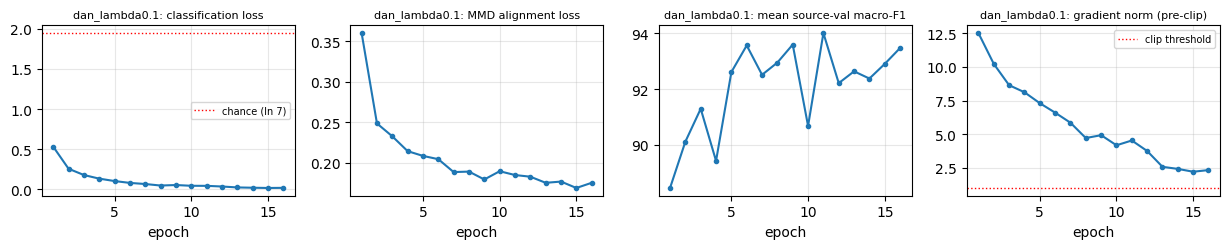

$ python -m task2.train --config task2/configs/study_dan_lambda10.yaml --set data_root=/content/data/PACS
[dan_lambda10] ep01 loss_cls=1.9448 loss_mmd=0.2428 loss_total=4.3731 | val mean F1=5.07
[dan_lambda10] ep02 loss_cls=1.9384 loss_mmd=0.2307 loss_total=4.2459 | val mean F1=5.07
[dan_lambda10] ep03 loss_cls=1.9383 loss_mmd=0.2229 loss_total=4.1674 | val mean F1=5.07
[dan_lambda10] ep04 loss_cls=1.9347 loss_mmd=0.2248 loss_total=4.1822 | val mean F1=5.07
[dan_lambda10] ep05 loss_cls=1.9327 loss_mmd=0.2079 loss_total=4.0121 | val mean F1=5.07
[dan_lambda10] ep06 loss_cls=1.9298 loss_mmd=0.2134 loss_total=4.0637 | val mean F1=5.07
early stop at epoch 6 (best mean macro-F1 5.07)

=== dan_lambda10 ===
  epochs run              : 6 of 30 (early stop)
  best source-val macro-F1: 5.07  (epoch 1 -- this checkpoint is the one saved)
  classification loss     : 1.945 -> 1.930   (1.95 = chance for 7 classes)
  MMD alignment loss      : 0.243 -> 0.213
  gradient norm           : max 1670.74, cl

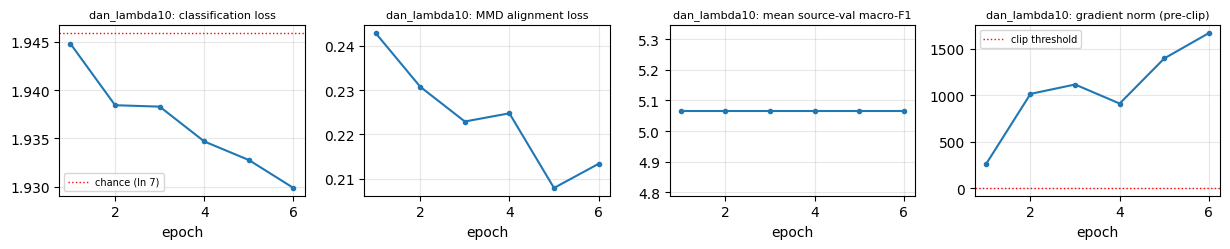

In [13]:
# B5 + B6. The controlled study: the two extra alignment strengths. The middle setting is the main run above,
# so only two more trainings are needed. Everything else is held fixed.
for c, r in RUNS[4:]:
    train(c, r)

In [14]:
# B7. All runs side by side, on source information only. Check this before moving to Part C.
rows = []
for c, r in RUNS:
    p, h = f'task2/results/runs/{r}/summary.json', f'task2/results/runs/{r}/history.json'
    if not os.path.exists(p):
        rows.append({'run': r, 'status': 'NOT RUN'}); continue
    s, hist = json.load(open(p)), json.load(open(h))
    cls, gn = [e['loss_cls'] for e in hist], [e.get('grad_norm', float('nan')) for e in hist]
    status = ('COLLAPSED' if min(cls) > 1.6 or s['best_mean_macro_f1'] < 50 else
              'unstable' if cls[-1] > 1.6 or s['best_mean_macro_f1'] < 80 else 'ok')
    rows.append({'run': r, 'status': status, 'epochs': s['epochs_run'],
                 'best_src_val_f1': round(s['best_mean_macro_f1'], 2),
                 'final_loss_cls': round(cls[-1], 3), 'max_grad_norm': round(max(gn), 2),
                 'clipped_epochs': sum(g > CLIP for g in gn if g == g)})
tbl = pd.DataFrame(rows)
display(tbl)
bad = tbl[tbl.status.isin(['COLLAPSED', 'unstable', 'NOT RUN'])].run.tolist()
print('All six runs trained cleanly -- go on to Part C.' if not bad else
      f'Problem runs: {bad}. Send their report() output to Claude before running Part C;\n'
      f'evaluating a collapsed run measures the collapse, not the method.')

,run,status,epochs,best_src_val_f1,final_loss_cls,max_grad_norm,clipped_epochs
0,source_only,ok,15,93.88,0.069,13.04,15
1,dan,ok,18,93.70,0.056,10.30,18
2,dann,unstable,9,77.51,238.763,8016248.60,9
3,cdan,ok,13,93.39,0.895,7144090.06,13
4,dan_lambda0.1,ok,16,94.01,0.019,12.52,16
5,dan_lambda10,COLLAPSED,6,5.07,1.930,1670.74,6


Problem runs: ['dann', 'dan_lambda10']. Send their report() output to Claude before running Part C;
evaluating a collapsed run measures the collapse, not the method.


## Part C — final evaluation

This is the **first and only** place Sketch labels are read. Everything is frozen by now: checkpoints,
configs, the study setting.

For each checkpoint the script computes:
1. accuracy and macro-F1 on each of the three source validation splits, and their mean;
2. accuracy and macro-F1 on all 3,929 sketches, plus the change versus Source-only;
3. **domain separability**: freeze the backbone, take equal numbers of source-validation and sketch
   features, throw away the class labels and relabel by domain, then train a balanced logistic
   regression (C = 1, seed-6304 70/30 split) to predict the domain. 50% means the domains are
   indistinguishable from the features; ~100% means domain identity is still obvious;
4. per-class Sketch accuracy, the largest gain and drop versus Source-only, and their confusions.

A low separability score means only that *domain* information is hard to recover. It says nothing about
whether *class* information survived, which is why it must be read next to Sketch accuracy.

In [15]:
# C1. Run the final evaluation (main comparison, then the controlled study), and print the headline numbers.
missing = [r for _, r in RUNS if not os.path.exists(f'task2/results/runs/{r}/summary.json')]
assert not missing, f'Unfinished runs: {missing} -- finish Part B first'
run('python -m task2.evaluate_final')
run(f'python -m task2.evaluate_final --study {STUDY}')

F = 'task2/results/final'
main = pd.read_csv(f'{F}/table_main.csv')
base = main[main.method == 'source_only'].iloc[0]
print('\n================ MAIN COMPARISON ================')
print(f'Source-only domain gap: {base.mean_src_acc:.2f}% on source validation vs {base.target_acc:.2f}% on Sketch'
      f'  ->  {base.mean_src_acc - base.target_acc:.2f} points lost by changing domain.\n')
for _, r in main.iterrows():
    tag = 'baseline' if r.method == 'source_only' else f'{r.delta_target_acc:+.2f} pts vs baseline'
    print(f'  {r.method:12s} source-val {r.mean_src_f1:5.2f} F1 | Sketch {r.target_acc:5.2f}% acc, {r.target_f1:5.2f} F1 '
          f'| separability {r.domain_sep:5.2f}%  ({tag})')
print('\nRead the last two columns together: alignment is only useful if lower separability comes with')
print('higher Sketch accuracy. If separability falls while Sketch accuracy drops, that is negative transfer.')

$ python -m task2.evaluate_final
     method  best_epoch  photo_acc  photo_f1  art_painting_acc  art_painting_f1  cartoon_acc  cartoon_f1  mean_src_acc  mean_src_f1  target_acc  target_f1  domain_sep  delta_target_acc
source_only          10      95.81     95.16             91.46            91.52        94.46       94.96         93.91        93.88       65.33      63.70       99.86              0.00
        dan          13      97.60     97.18             88.78            88.98        94.46       94.94         93.61        93.70       56.81      52.60       87.23             -8.53
       dann           4      86.83     84.95             68.78            64.96        82.94       82.63         79.52        77.51       43.73      44.31       99.86            -21.61
       cdan           8      96.71     96.13             90.49            90.43        93.18       93.62         93.46        93.39       20.18      20.29       98.90            -45.15
$ python -m task2.evaluate_final --study d

In [16]:
# C2. The controlled study: what increasing alignment pressure did to the three quantities the handout names.
study = pd.read_csv(f'{F}/table_study_{STUDY}.csv')
display(study.round(2))
print(f'Source-only reference: Sketch {base.target_acc:.2f}% acc, separability {base.domain_sep:.2f}%\n')
for _, r in study.iterrows():
    print(f'  {r.setting:12s} source-val {r.mean_src_f1:5.2f} F1 | separability {r.domain_sep:5.2f}% | Sketch {r.target_acc:5.2f}%')
best_src = study.loc[study.mean_src_f1.idxmax()]
best_tgt = study.loc[study.target_acc.idxmax()]
print(f'\nChosen WITHOUT target labels (highest source-val F1): {best_src.setting}')
print(f'Best on Sketch, known only now                      : {best_tgt.setting}')
print('If those disagree, say so in RQ4: it shows the limits of label-free model selection.')

,setting,method,best_epoch,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_src_acc,mean_src_f1,target_acc,target_f1,domain_sep
0,lambda=0.1,dan_lambda0.1,11,95.51,94.90,91.71,92.02,94.88,95.12,94.03,94.01,70.20,64.68,91.48
1,lambda=1,dan,13,97.60,97.18,88.78,88.98,94.46,94.94,93.61,93.70,56.81,52.60,87.23
2,lambda=10,dan_lambda10,1,25.75,5.85,21.95,5.14,17.27,4.21,21.66,5.07,4.07,1.12,69.92


Source-only reference: Sketch 65.33% acc, separability 99.86%

  lambda=0.1   source-val 94.01 F1 | separability 91.48% | Sketch 70.20%
  lambda=1     source-val 93.70 F1 | separability 87.23% | Sketch 56.81%
  lambda=10    source-val  5.07 F1 | separability 69.92% | Sketch  4.07%

Chosen WITHOUT target labels (highest source-val F1): lambda=0.1
Best on Sketch, known only now                      : lambda=0.1
If those disagree, say so in RQ4: it shows the limits of label-free model selection.


In [17]:
# C3. Class-level analysis: does an aggregate number hide class-specific damage?
pc = pd.read_csv(f'{F}/per_class_target_acc.csv', index_col=0)
print('Per-class Sketch accuracy (%):'); display(pc.round(2))
print('Change versus Source-only (percentage points):')
display(pc.drop(columns=['source_only']).sub(pc['source_only'], axis=0).round(2))

ana = json.load(open(f'{F}/class_analysis.json'))
print(f'\nSource-only is weakest on "{ana["source_only_weakest_class"]}". Its mistakes there go to:')
for c in ana['source_only_confusions'][ana['source_only_weakest_class']]:
    print(f'   -> {c["pred"]:9s} {c["count"]:4d} images ({c["share_%"]:.1f}% of that class)')
for m in [r for r in main.method if r != 'source_only']:
    g, d = ana[m]['largest_gain'], ana[m]['largest_drop']
    print(f'\n{m}:')
    print(f'   biggest gain : {g["class"]:9s} {g["delta_pp"]:+.1f} pts')
    print(f'   biggest drop : {d["class"]:9s} {d["delta_pp"]:+.1f} pts  -- those images now go to: '
          + ', '.join(f'{c["pred"]} ({c["share_%"]:.0f}%)' for c in d['confusions_after'][:2]))
print('\nSketch has far fewer images of some classes than others, so a few classes move in large jumps.')
print('Cell C5 prints the counts; quote them whenever you cite one of these percentages.')

Per-class Sketch accuracy (%):


,source_only,dan,dann,cdan
dog,9.46,33.55,1.04,0.65
elephant,86.08,70.68,99.32,4.73
giraffe,65.87,65.60,30.54,15.80
guitar,80.26,72.70,74.67,73.36
horse,81.00,52.21,20.96,3.19
house,96.25,100.00,67.50,2.50
person,84.38,5.00,41.25,100.00


Change versus Source-only (percentage points):


,dan,dann,cdan
dog,24.09,-8.42,-8.81
elephant,-15.41,13.24,-81.35
giraffe,-0.27,-35.33,-50.07
guitar,-7.57,-5.59,-6.91
horse,-28.80,-60.05,-77.82
house,3.75,-28.75,-93.75
person,-79.38,-43.12,15.62



Source-only is weakest on "dog". Its mistakes there go to:
   -> elephant   272 images (35.2% of that class)
   -> horse      253 images (32.8% of that class)
   -> person     104 images (13.5% of that class)

dan:
   biggest gain : dog       +24.1 pts
   biggest drop : person    -79.4 pts  -- those images now go to: house (95%)

dann:
   biggest gain : elephant  +13.2 pts
   biggest drop : horse     -60.0 pts  -- those images now go to: elephant (76%), person (2%)

cdan:
   biggest gain : person    +15.6 pts
   biggest drop : house     -93.8 pts  -- those images now go to: person (98%)

Sketch has far fewer images of some classes than others, so a few classes move in large jumps.
Cell C5 prints the counts; quote them whenever you cite one of these percentages.



--- failures_cdan_house.png ---
Failure cases: images this method gets wrong that Source-only got right


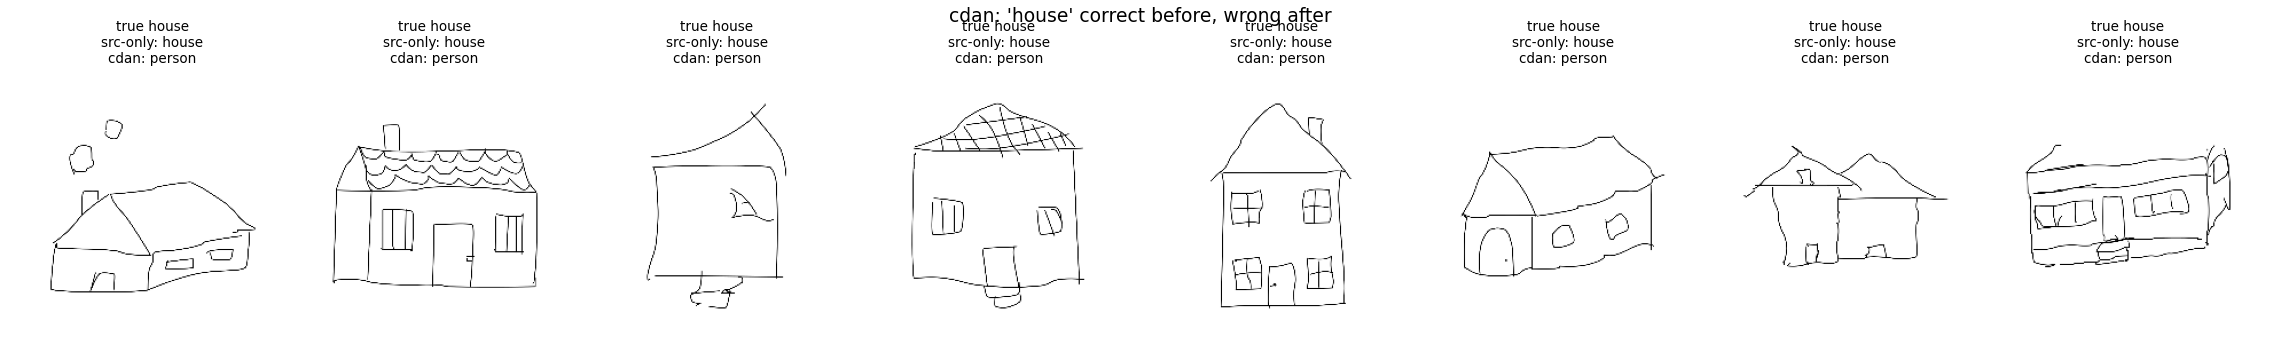


--- failures_dan_person.png ---
Failure cases: images this method gets wrong that Source-only got right


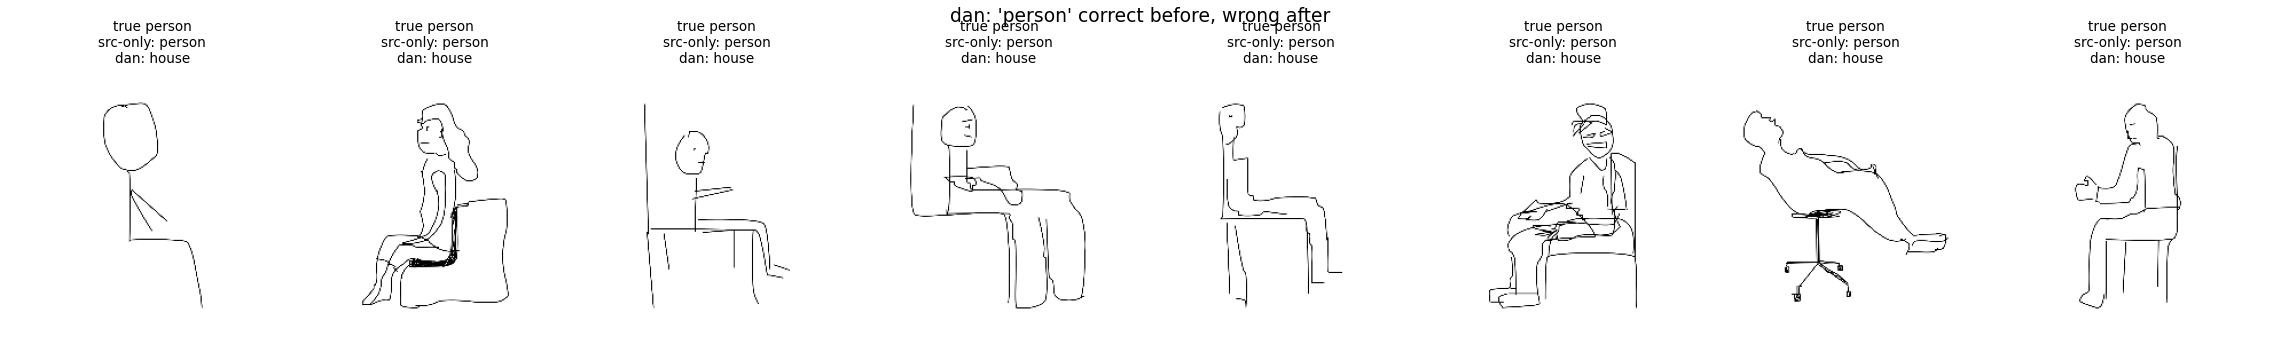


--- failures_dann_horse.png ---
Failure cases: images this method gets wrong that Source-only got right


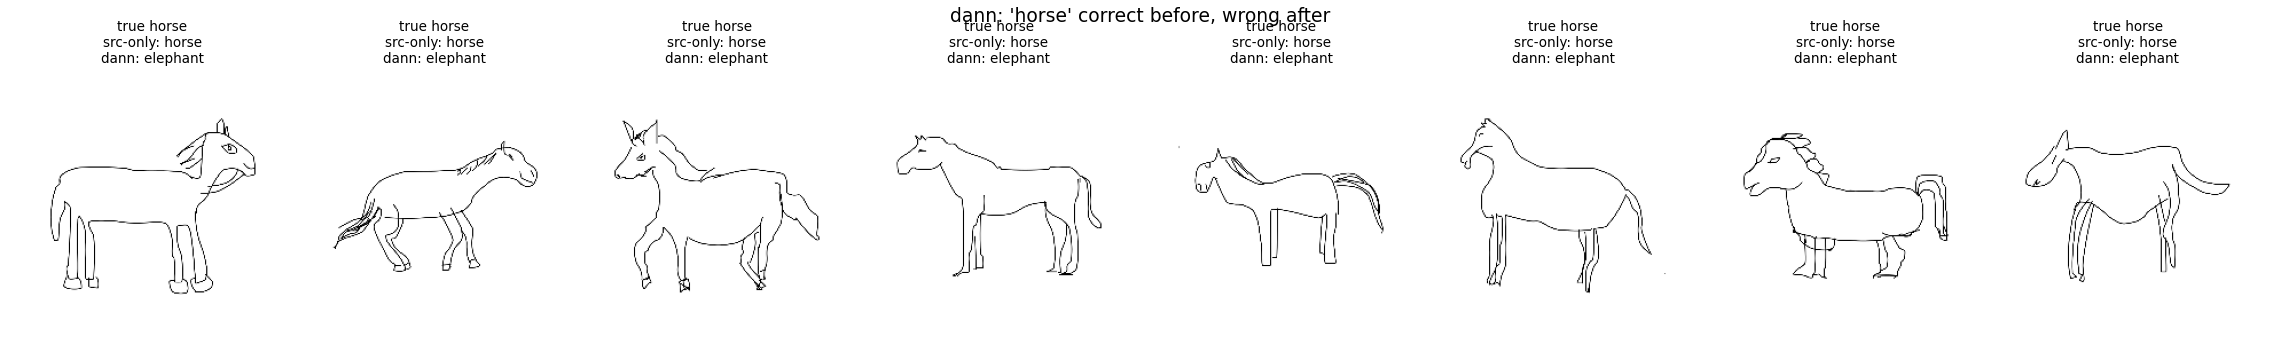


--- failures_source_only_dog.png ---
Failure cases: images this method gets wrong that Source-only got right


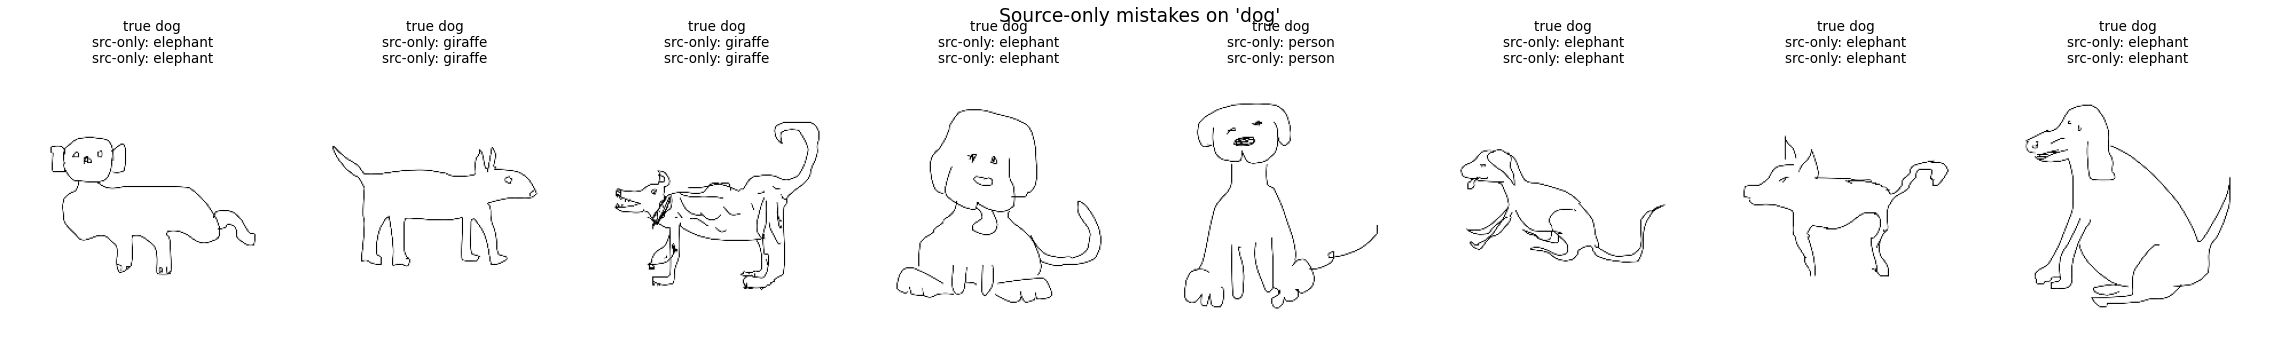


--- per_class_delta.png ---
Required evidence: per-class Sketch accuracy change vs Source-only -- where transfer helped and where it hurt


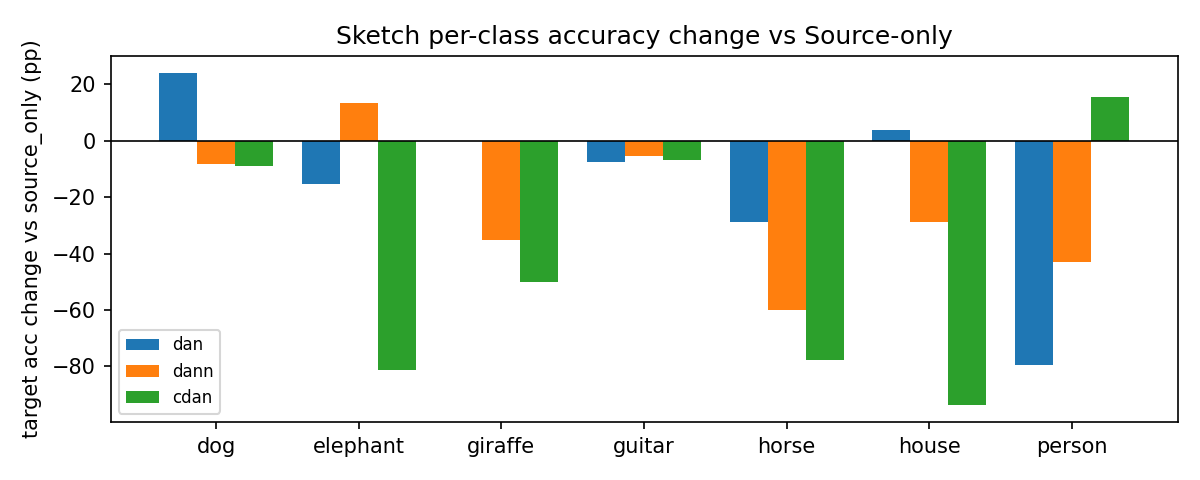


--- study_dan.png ---
Controlled study: source performance, separability and Sketch accuracy against alignment strength


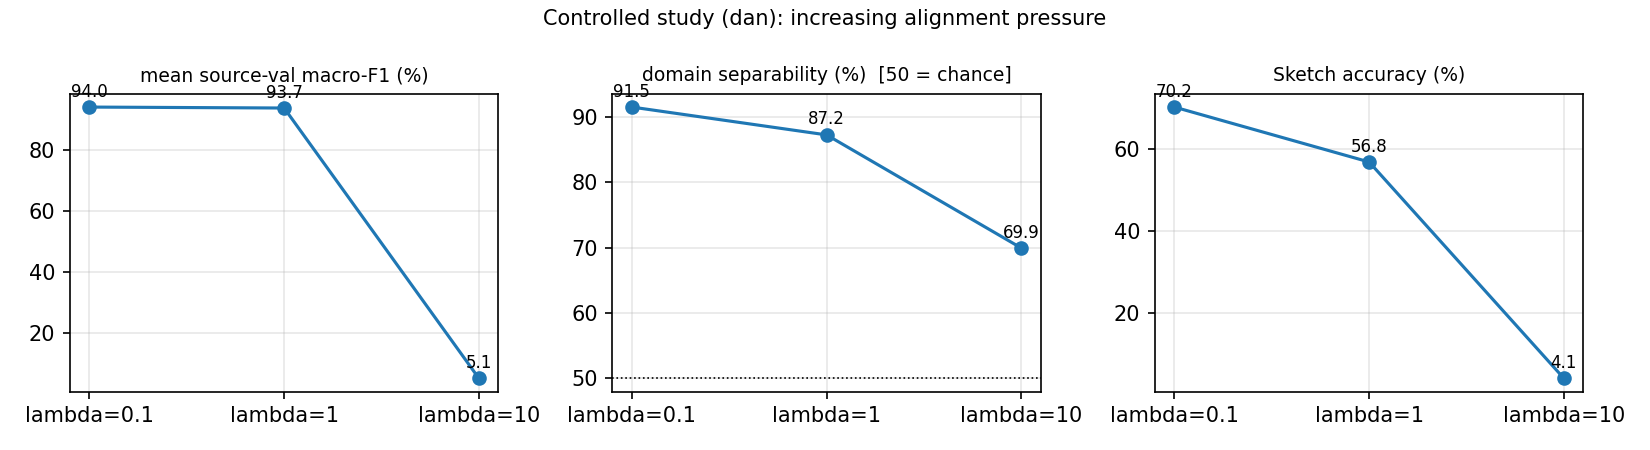


--- training_curves.png ---
Required evidence: did each method train as intended? (class loss, alignment/domain loss, discriminator accuracy, source-val F1)


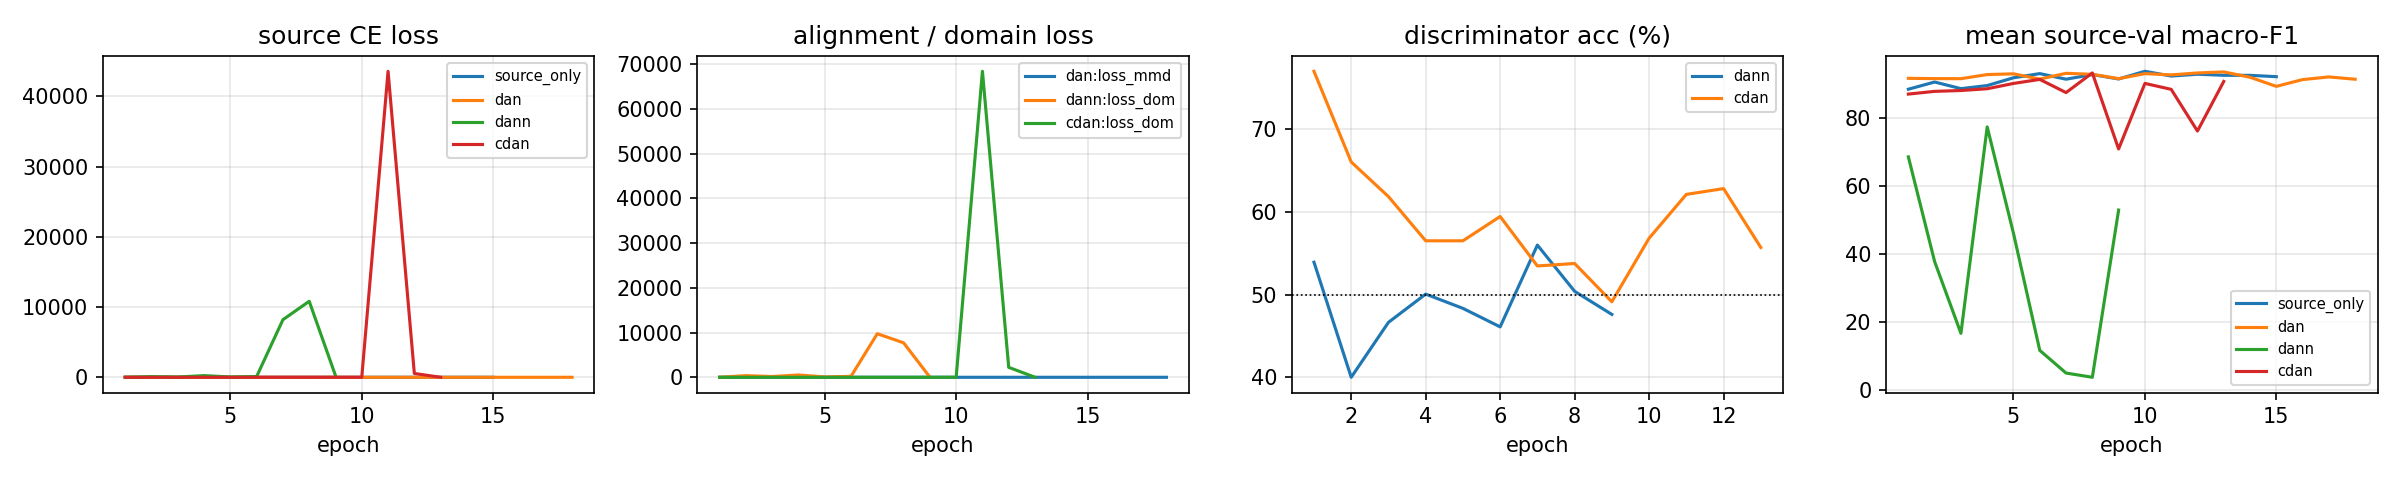


--- training_curves_study_dan.png ---
Curves for the study runs


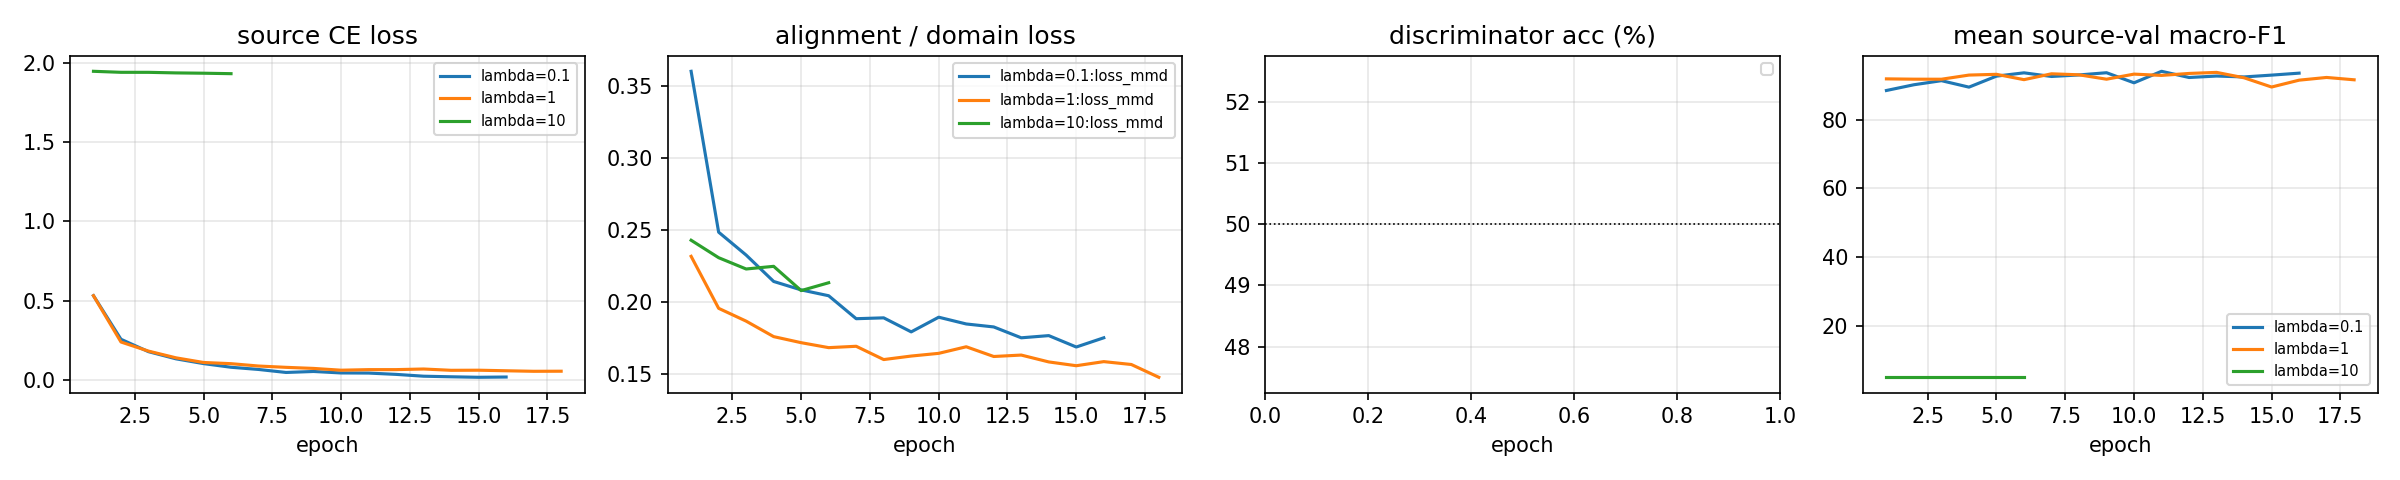

In [18]:
# C4. Every figure, with a note on what each one is for.
from IPython.display import Image, display as show
CAPTIONS = {
    'training_curves.png': 'Required evidence: did each method train as intended? (class loss, alignment/domain loss, discriminator accuracy, source-val F1)',
    'per_class_delta.png': 'Required evidence: per-class Sketch accuracy change vs Source-only -- where transfer helped and where it hurt',
    'study_dan.png': 'Controlled study: source performance, separability and Sketch accuracy against alignment strength',
    'study_dann.png': 'Controlled study: source performance, separability and Sketch accuracy against alignment strength',
    'training_curves_study_dan.png': 'Curves for the study runs',
    'training_curves_study_dann.png': 'Curves for the study runs',
}
for p in sorted(glob.glob(f'{F}/figures/*.png')):
    name = os.path.basename(p)
    note = CAPTIONS.get(name, 'Failure cases: images this method gets wrong that Source-only got right'
                              if name.startswith('failures_') else '')
    print(f'\n--- {name} ---\n{note}')
    show(Image(p))

In [19]:
# C5. Analysis only: class shares per domain. This reads Sketch labels, so it belongs here, after
# everything is locked. Zhao et al. (2019) show that aligning domains whose class proportions differ
# raises a floor on the combined error -- i.e. it predicts exactly the kind of per-class damage in C3.
import collections
from shared.pacs import CLASSES
counts = {d: collections.Counter(y for _, y in s['train'] + s['val']) for d, s in src.items()}
counts['sketch'] = collections.Counter(y for _, y in json.load(open('shared/splits/pacs_sketch_target.json'))['items'])
cnt = pd.DataFrame(counts).sort_index().rename(index=dict(enumerate(CLASSES)))
print('Images per class:'); display(cnt)
share = (100 * cnt / cnt.sum()).round(1)
print('Class share (%) -- compare the sketch column with the three source columns:'); display(share)
diff = (share['sketch'] - share[[c for c in share.columns if c != 'sketch']].mean(axis=1)).round(1)
print('Sketch share minus average source share (pts):'); print(diff.sort_values().to_string())

Images per class:


,photo,art_painting,cartoon,sketch
dog,189,379,389,772
elephant,202,255,457,740
giraffe,182,285,346,753
guitar,186,184,135,608
horse,199,201,324,816
house,280,295,288,80
person,432,449,405,160


Class share (%) -- compare the sketch column with the three source columns:


,photo,art_painting,cartoon,sketch
dog,11.3,18.5,16.6,19.6
elephant,12.1,12.5,19.5,18.8
giraffe,10.9,13.9,14.8,19.2
guitar,11.1,9.0,5.8,15.5
horse,11.9,9.8,13.8,20.8
house,16.8,14.4,12.3,2.0
person,25.9,21.9,17.3,4.1


Sketch share minus average source share (pts):
person     -17.6
house      -12.5
dog          4.1
elephant     4.1
giraffe      6.0
guitar       6.9
horse        9.0


## Part D — package for GitHub

The zip contains exactly the files git would commit: code, configs, split indices, result tables,
figures and READMEs. Checkpoints (`*.pt`), the dataset and caches are excluded by `.gitignore`.

In [20]:
# D1. Build the GitHub zip and report what went into it.
!rm -rf /tmp/gitcheck && git init -q /tmp/gitcheck
!git --git-dir=/tmp/gitcheck/.git --work-tree=. ls-files --others --exclude-standard > /tmp/commit_list.txt
n = len(open('/tmp/commit_list.txt').read().split())
splits = sum(1 for l in open('/tmp/commit_list.txt') if l.startswith('shared/splits/'))
print(f'{n} files to commit; {splits} split files (should be 2).')
!du -ch $(cat /tmp/commit_list.txt) | tail -1
!rm -f "{DRIVE}/PA1_github.zip" && zip -q -@ "{DRIVE}/PA1_github.zip" < /tmp/commit_list.txt
print('\nSaved My Drive/PA1_github.zip -- download it, unzip into your local clone, commit and push.')

123 files to commit; 2 split files (should be 2).
27M	total

Saved My Drive/PA1_github.zip -- download it, unzip into your local clone, commit and push.


## Troubleshooting
- **A run is flagged COLLAPSED or unstable in B7:** send its `report()` output (summary + curves) to Claude. The next diagnostic is usually `study_dann_alpha0.25.yaml`, which tests whether weaker alignment pressure trains stably.
- **`FileNotFoundError: No images under ...`:** PACS isn't where the code expects it; check A5's counts.
- **`CUDA out of memory`:** Runtime → Restart session, re-run Part A. Don't change batch sizes; the handout fixes them.
- **Want to redo one run:** delete its folder under `task2/results/runs/` and re-run its cell.
- **Session died mid-run:** re-run Part A, then the same B cell. Finished runs are skipped automatically.